### Lab 7
#### 7.8.1 Polynomial Regression and Step Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
wage = pd.read_csv("data/Wage.csv")

model_raw = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage).fit()
print("--- Row polinomial ---")
print(model_raw.summary())

--- Row polinomial ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     70.69
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.77e-57
Time:                        13:41:36   Log-Likelihood:                -15315.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2995   BIC:                         3.067e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -184.1542     

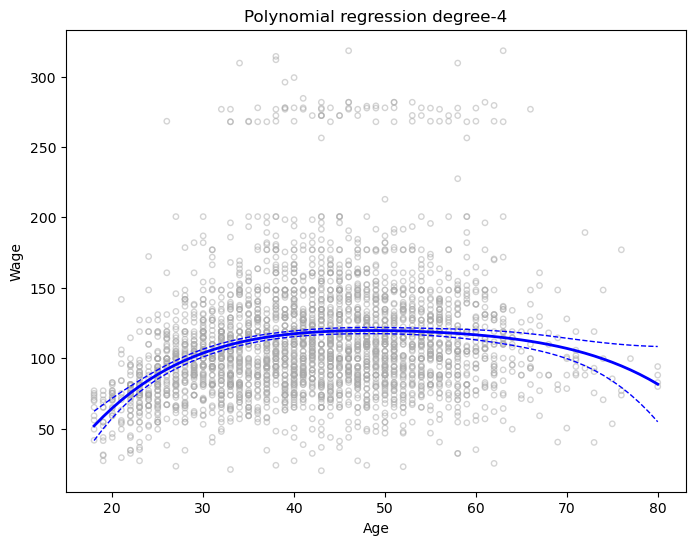

In [8]:
age_grid = pd.DataFrame({"age": np.arange(wage.age.min(), wage.age.max() + 1)})

predictions = model_raw.get_prediction(age_grid)
pred_summary = predictions.summary_frame(alpha=0.05)

plt.figure(figsize=(8, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, pred_summary["mean"], color="blue", lw=2, label="Degree-4 Polynomial")
plt.plot(age_grid.age, pred_summary["mean_ci_lower"], color="blue", linestyle="--", lw=1)
plt.plot(age_grid.age, pred_summary["mean_ci_upper"], color="blue", linestyle="--", lw=1)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Polynomial regression degree-4")
plt.show()

Based on the chart and calculated table above, we can draw next conclusions:
- The model captured the underlying trend and generated a smooth curve through the data point cloud
- the train accuracy is quite low $R^2=0.086$, only 8% of wage variance was explained
- Three features (age, $age^2$, and $age^3$) turned out to be statistically significant
- The 4th-degree polynomial term is strictly non-significant at the 5% level ($p = 0.051$)
- The confidence intervals widen at both tails of the curve due to less data density at the age extremes

In [12]:
wage["age_bins"] = pd.cut(wage.age, bins=4)

print("\n--- Bins distribution ---")
print(wage["age_bins"].value_counts().sort_index())

model_bins = smf.ols(formula="wage ~ age_bins", data=wage).fit()
print("\n--- The step function result ---")
print(model_bins.summary().tables[1])


--- Bins distribution ---
age_bins
(17.938, 33.5]     750
(33.5, 49.0]      1399
(49.0, 64.5]       779
(64.5, 80.0]        72
Name: count, dtype: int64

--- The step function result ---
                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           94.1584      1.476     63.790      0.000      91.264      97.053
age_bins[T.Interval(33.5, 49.0, closed='right')]    24.0535      1.829     13.148      0.000      20.466      27.641
age_bins[T.Interval(49.0, 64.5, closed='right')]    23.6646      2.068     11.443      0.000      19.610      27.719
age_bins[T.Interval(64.5, 80.0, closed='right')]     7.6406      4.987      1.532      0.126      -2.139      17.420


After performing step function on the full data set we can clearly see that, the feature Age was divided on 4 groups (dummy variable). The youngest age group was automatically selected as the reference (baseline) category

The baseline mean wage for the youngest group (ages 17.9 to 33.5) is 94.16. As age increases, the first significant shift occurs in the second group (ages 33.5 to 49.0), increasing the mean wage by 24.05 to a total of 118.21, and so on

The oldest age group (ages 64.5 to 80.0) shows the smallest mean increase (7.64), which is statistically indistinguishable from the baseline group ($p = 0.126$)

In [15]:
from statsmodels.stats.anova import anova_lm

fit_1 = smf.ols(formula="wage ~ age", data=wage).fit()
fit_2 = smf.ols(formula="wage ~ age + I(age**2)", data=wage).fit()
fit_3 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3)", data=wage).fit()
fit_4 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage).fit()
fit_5 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4) + I(age**5)", data=wage).fit()

anova_results = anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5)
print(anova_results)

   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


The ANOVA analysis showed:

The 4th-degree polynomial model is on the verge of statistical significance ($p \approx 0.051$).

While the 2nd-degree polynomial provides the largest marginal improvement in fit ($F = 143.59$), the sequential ANOVA test suggests that the cubic (3rd-degree) term is still highly statistically significant ($p = 0.0017$). Therefore, a 3rd or 4th-degree polynomial should be preferred to avoid underfitting

#### 7.8.2 Splines

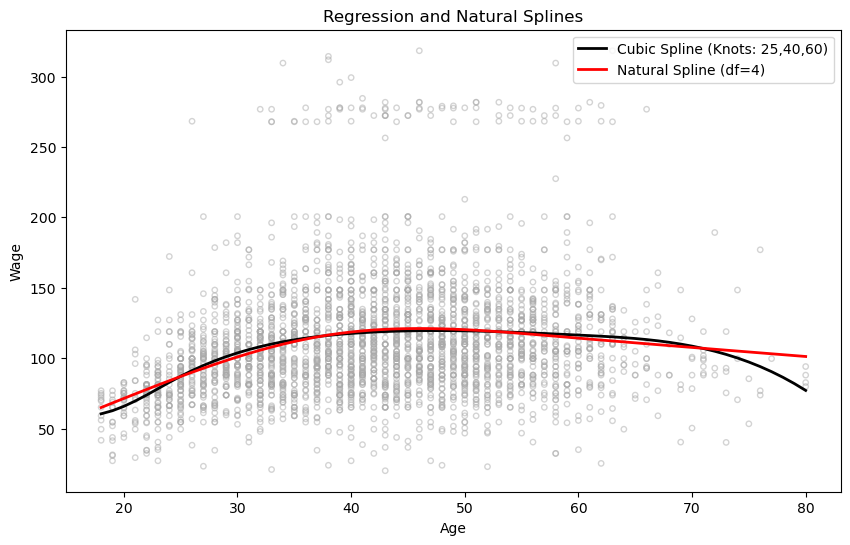

In [21]:
age_grid = pd.DataFrame({'age': np.arange(wage.age.min(), wage.age.max() + 1)})

# cubic spline with knots - 25, 40, 60
fit_cubic = smf.ols(formula="wage ~ bs(age, knots=(25, 40, 60), degree=3)", data=wage).fit()
preds_cubic = fit_cubic.get_prediction(age_grid).summary_frame()

# 2. natural spline with df=4
fit_natural = smf.ols(formula="wage ~ cr(age, df=4)", data=wage).fit()
preds_natural = fit_natural.get_prediction(age_grid).summary_frame()

plt.figure(figsize=(10, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, preds_cubic["mean"], color="black", lw=2, label="Cubic Spline (Knots: 25,40,60)")
plt.plot(age_grid.age, preds_natural["mean"], color="red", lw=2, label="Natural Spline (df=4)")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Regression and Natural Splines")
plt.legend()
plt.show()

The Natural Spline exhibits a linear behavior at the boundaries because of its inherent constraints: the function is forced to be linear for values of X smaller than the leftmost knot or larger than the rightmost knot

This boundary constraint effectively reduces the variance at the extremes. In contrast, the standard Cubic Spline lacks these constraints, making its tails unstable and prone to high variance in regions with sparse data

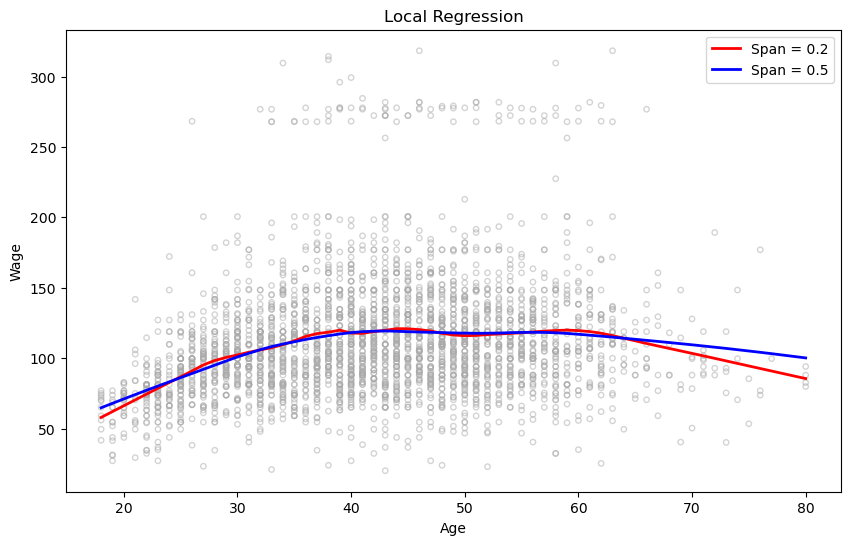

In [22]:
from statsmodels.nonparametric.smoothers_lowess import lowess

lowess_02 = lowess(wage.wage, wage.age, frac=0.2, it=0)
lowess_05 = lowess(wage.wage, wage.age, frac=0.5, it=0)

plt.figure(figsize=(10, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(lowess_02[:, 0], lowess_02[:, 1], color='red', lw=2, label="Span = 0.2")
plt.plot(lowess_05[:, 0], lowess_05[:, 1], color="blue", lw=2, label="Span = 0.5")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Local Regression")
plt.legend()
plt.show()

The local regression model with a span of 0.2 displays a more fluctuating shape. It has a higher variance, which increases the risk of overfitting to local noise

first glance, both models successfully capture the overarching macro-trend, but the span of 0.5 offers a much more stable and robust generalization

In [70]:
from pygam import LinearGAM, s

X = wage["age"].values.reshape(-1, 1)
y = wage["wage"].values

gam_16 = LinearGAM(s(0, n_splines=16)).fit(X, y)

gam_cv = LinearGAM(s(0)).gridsearch(X, y)

gam_cv.summary()

age_grid_vals = age_grid["age"].values.reshape(-1, 1)
pred_16 = gam_16.predict(age_grid_vals)
pred_cv = gam_cv.predict(age_grid_vals)

plt.figure(figsize=(10, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, pred_16, color="red", lw=2, label="16 Degrees of Freedom")
plt.plot(age_grid.age, pred_cv, color="blue", lw=2, label=f'{gam_cv.statistics_["edof"]:.1f} Effective DF (GCV)')
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Smoothing Spline")
plt.legend()
plt.show()

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                       5.644
Link Function:                     IdentityLink Log Likelihood:                                -15312.6161
Number of Samples:                         3000 AIC:                                              30638.52
                                                AICc:                                            30638.554
                                                GCV:                                             1596.8792
                                                Scale:                                             39.8933
                                                Pseudo R-Squared:                                   0.0874
Feature Function                  Lam

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

The curve generated by the smoothing spline with 5.6 effective degrees of freedom (EDoF) exhibits a more stable and generalized trend

A smaller number of effective degrees of freedom restricts model flexibility, thereby minimizing variance

As shown in the chart, a higher degree of freedom ($df=16$) causes the model to capture local noise, leading to artificial fluctuations and a higher risk of overfitting. This is especially true for this dataset, where the underlying macro-relationship is relatively simple and smooth

#### 7.8.3 GAMs

--- ANOVA TABLE ---
   df_resid           ssr  df_diff      ss_diff          F    Pr(>F)
0    2991.0  3.717318e+06      0.0          NaN        NaN       NaN
1    2990.0  3.700612e+06      1.0  16706.49743  13.495266  0.000243
2    2988.0  3.699002e+06      2.0   1609.69955   0.650146  0.522043


C:\Users\ilyas\AppData\Local\Temp\ipykernel_2764\3652321696.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")


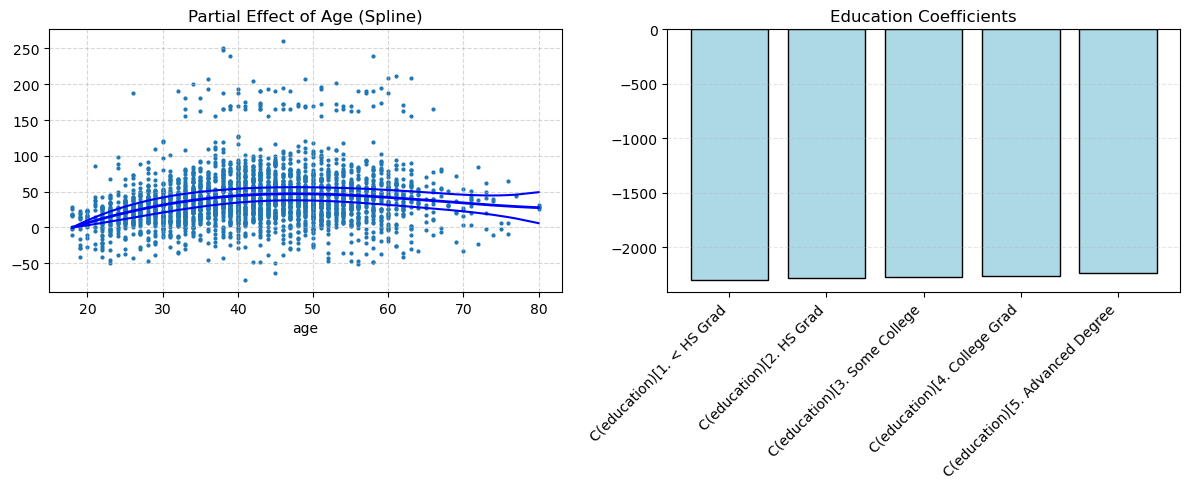

In [47]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

gam_m1 = smf.ols(formula="wage ~ cr(age, df=5) + C(education)", data=wage).fit()
gam_m2 = smf.ols(formula="wage ~ year + cr(age, df=5) + C(education)", data=wage).fit()
gam_m3 = smf.ols(formula="wage ~ cr(year, df=4) + cr(age, df=5) + C(education)", data=wage).fit()

print("--- ANOVA TABLE ---")
print(anova_lm(gam_m1, gam_m2, gam_m3))


x_spline = wage[["age"]]
bs = BSplines(x_spline, df=[5], degree=[3])

from patsy import dmatrix
X_linear = dmatrix("year + C(education) -1", data=wage, return_type="dataframe")

gam_model = GLMGam(wage["wage"], exog=X_linear, smoother=bs).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gam_model.plot_partial(smooth_index=0, ax=axes[0], cpr=True)
axes[0].set_title("Partial Effect of Age (Spline)")
axes[0].grid(True, linestyle="--", alpha=0.5)

edu_coefs = gam_model.params[gam_model.params.index.str.contains("education")]
edu_labels = [label.split("[T.")[-1].split("]")[0] for label in edu_coefs.index]

axes[1].bar(edu_labels, edu_coefs.values, color="lightblue", edgecolor="black")
axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")
axes[1].set_title("Education Coefficients")
axes[1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Incorporating a linear term for 'year' (Model 2) into the base model significantly improves the fit ($F = 13.50, p = 0.00024$)

Upgrading 'year' to a non-linear natural spline (Model 3) does not make statistical sense, as the F-statistic drops sharply ($F = 0.65$) and the p-value is highly non-significant ($p = 0.522$)

--- ANOVA TABLE ---
   df_resid           ssr  df_diff      ss_diff          F    Pr(>F)
0    2991.0  3.717318e+06      0.0          NaN        NaN       NaN
1    2990.0  3.700612e+06      1.0  16706.49743  13.495266  0.000243
2    2988.0  3.699002e+06      2.0   1609.69955   0.650146  0.522043


C:\Users\ilyas\AppData\Local\Temp\ipykernel_2764\1590433225.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")


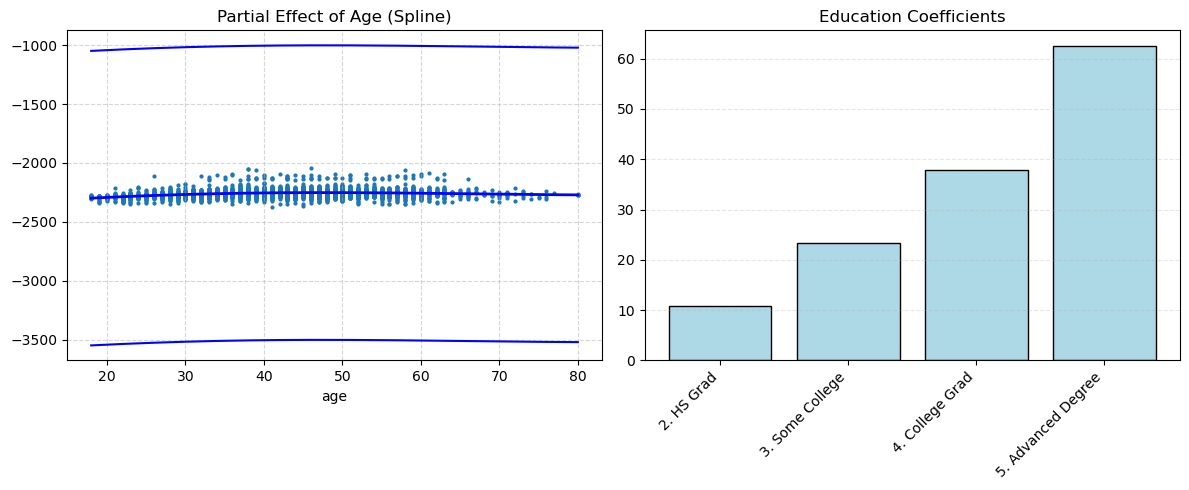

In [48]:
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

gam_m1 = smf.ols(formula="wage ~ cr(age, df=5) + C(education)", data=wage).fit()
gam_m2 = smf.ols(formula="wage ~ year + cr(age, df=5) + C(education)", data=wage).fit()
gam_m3 = smf.ols(formula="wage ~ cr(year, df=4) + cr(age, df=5) + C(education)", data=wage).fit()

print("--- ANOVA TABLE ---")
print(anova_lm(gam_m1, gam_m2, gam_m3))


x_spline = wage[["age"]]
bs = BSplines(x_spline, df=[5], degree=[3])

from patsy import dmatrix
X_linear = dmatrix("year + C(education)", data=wage, return_type="dataframe")

gam_model = GLMGam(wage["wage"], exog=X_linear, smoother=bs).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gam_model.plot_partial(smooth_index=0, ax=axes[0], cpr=True)
axes[0].set_title("Partial Effect of Age (Spline)")
axes[0].grid(True, linestyle="--", alpha=0.5)

edu_coefs = gam_model.params[gam_model.params.index.str.contains("education")]
edu_labels = [label.split("[T.")[-1].split("]")[0] for label in edu_coefs.index]

axes[1].bar(edu_labels, edu_coefs.values, color="lightblue", edgecolor="black")
axes[1].set_xticklabels(edu_labels, rotation=45, ha="right")
axes[1].set_title("Education Coefficients")
axes[1].grid(True, linestyle="--", alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

The wage is increasing with every new stage of education

### Exercises

#### Task 6

In this exercise, you will further analyze the Wage data set considered
throughout this chapter

In [50]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# 1. download the data
wages = pd.read_csv("data/Wage.csv")
X = wages[["age"]].values
y = wages["wage"].values

# Cross-validation settings
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_list = []

# 2. run loop
for d in range(1, 6):
    # create polynomial features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    
    mse_scores = -cross_val_score(model, X_poly, y, cv=kf, scoring="neg_mean_squared_error")
    mean_mse = np.mean(mse_scores)
    
    scores_list.append((d, mean_mse))
    print(f"Polynomial degree {d}: Mean MSE = {mean_mse:.2f}")

best_d = min(scores_list, key=lambda x: x[1])[0]
print(f"\nCross-Validation chosen degree d = {best_d}")

Polynomial degree 1: Mean MSE = 1677.29
Polynomial degree 2: Mean MSE = 1600.84
Polynomial degree 3: Mean MSE = 1596.85
Polynomial degree 4: Mean MSE = 1596.66
Polynomial degree 5: Mean MSE = 1596.81

Cross-Validation chosen degree d = 4


The best MSE is 1596.66 for Polynomial degree 4

In [52]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

wage_anova = wages[["age", "wage"]].copy()

fit_1 = smf.ols("wage ~ age", data=wage_anova).fit()
fit_2 = smf.ols("wage ~ age + I(age**2)", data=wage_anova).fit()
fit_3 = smf.ols("wage ~ age + I(age**2) + I(age**3)", data=wage_anova).fit()
fit_4 = smf.ols("wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage_anova).fit()
fit_5 = smf.ols("wage ~ age + I(age**2) + I(age**3) + I(age**4) + I(age**5)", data=wage_anova).fit()

print(sm.stats.anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5, typ=1))

   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


Adding the 2nd-degree polynomial leads to the biggest reduction in RSS (and the largest F-statistic), with a $p\text{-value} = 2.36 \times 10^{-32}$, hence this is statistically significant.Adding the 3rd-degree polynomial is also highly significant ($p\text{-value} = 0.0017$). However, adding the 4th-degree polynomial is on the cultural boundary of significance with a $p\text{-value} = 0.051$. It can be considered marginally significant, which aligns well with our Cross-Validation results where the MSE plateaued after degree 3.The 5th-degree polynomial is clearly not statistically significant ($p\text{-value} = 0.37$). Therefore, an optimal choice would be either a cubic (3rd-degree) or quartic (4th-degree) polynomial

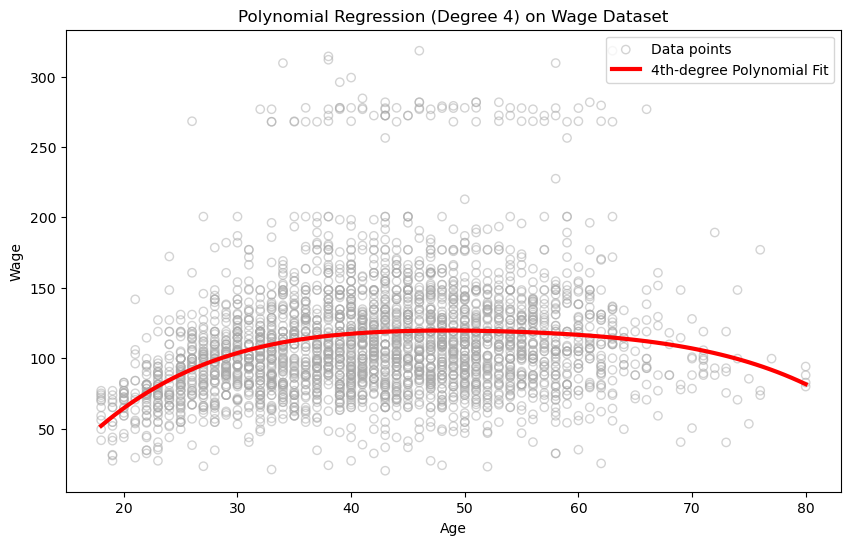

In [54]:
# fit the model with 4-th degree polynomial
poly_final = PolynomialFeatures(degree=4, include_bias=False)
X_poly_final = poly_final.fit_transform(X)
model_final = LinearRegression().fit(X_poly_final, y)

age_grid = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
age_grid_poly = poly_final.transform(age_grid)
y_pred = model_final.predict(age_grid_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, facecolors="none", edgecolors="darkgray", alpha=0.5, label="Data points")
plt.plot(age_grid, y_pred, color="red", lw=3, label="4th-degree Polynomial Fit")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Polynomial Regression (Degree 4) on Wage Dataset")
plt.legend()
plt.show()

The Polynomial Regression (degree 4) managed to catch the correct trend. The curve looks stable

In [55]:
from sklearn.preprocessing import OneHotEncoder

scores_step = []

for c in range(2, 11):
    age_cut = pd.cut(wages["age"], bins=c)
    
    encoder = OneHotEncoder(sparse_output=False)
    X_step = encoder.fit_transform(age_cut.values.reshape(-1, 1))
    
    model = LinearRegression()
    
    mse_scores = -cross_val_score(model, X_step, y, cv=kf, scoring="neg_mean_squared_error")
    mean_mse = np.mean(mse_scores)
    
    scores_step.append((c, mean_mse))
    print(f"Number of cuts {c}: Mean MSE = {mean_mse:.2f}")

best_c = min(scores_step, key=lambda x: x[1])[0]
print(f"\nCross-Validation chosen number of cuts = {best_c}")

Number of cuts 2: Mean MSE = 1735.21
Number of cuts 3: Mean MSE = 1682.40
Number of cuts 4: Mean MSE = 1636.83
Number of cuts 5: Mean MSE = 1631.77
Number of cuts 6: Mean MSE = 1623.09
Number of cuts 7: Mean MSE = 1614.74
Number of cuts 8: Mean MSE = 1603.21
Number of cuts 9: Mean MSE = 1611.56
Number of cuts 10: Mean MSE = 1605.97

Cross-Validation chosen number of cuts = 8


The best MSE is 1603.21 for 8 bins (cuts). Further increasing the number of cuts leads to overfitting, which increases the test MSE

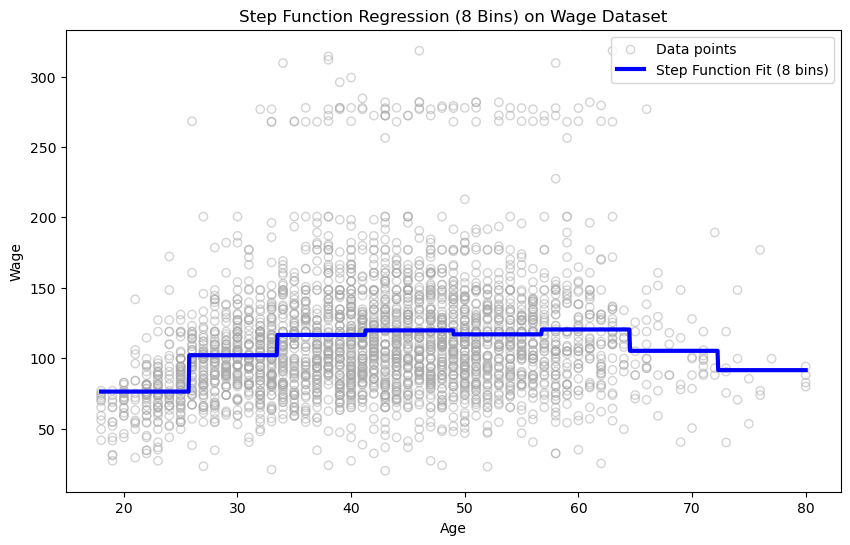

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

num_bins = 8
bin_edges = np.linspace(X.min(), X.max(), num_bins + 1)

X_bins = np.digitize(X.flatten(), bin_edges[:-1])

X_step_final = pd.get_dummies(X_bins, dtype=float).values

model_step_final = LinearRegression().fit(X_step_final, y)

age_grid = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)

age_grid_bins = np.digitize(age_grid.flatten(), bin_edges[:-1])

X_grid_step = pd.get_dummies(age_grid_bins, dtype=float)
X_grid_step = X_grid_step.reindex(columns=range(1, num_bins + 1), fill_value=0).values

y_pred_step = model_step_final.predict(X_grid_step)

# 4. Строим график
plt.figure(figsize=(10, 6))
plt.scatter(X, y, facecolors="none", edgecolors="darkgray", alpha=0.5, label="Data points")
plt.plot(age_grid, y_pred_step, color="blue", lw=3, label="Step Function Fit (8 bins)")
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Step Function Regression (8 Bins) on Wage Dataset")
plt.legend()
plt.show()

#### Task 7
The Wage data set contains a number of other features not explored
in this chapter, such as marital status (maritl), job class (jobclass),
and others. Explore the relationships between some of these other
predictors and wage, and use non-linear fitting techniques in order to
fit flexible models to the data. Create plots of the results obtained,
and write a summary of your findings.

Maritl:
maritl
2. Married          2074
1. Never Married     648
4. Divorced          204
5. Separated          55
3. Widowed            19
Name: count, dtype: int64

Education:
education
2. HS Grad            971
4. College Grad       685
3. Some College       650
5. Advanced Degree    426
1. < HS Grad          268
Name: count, dtype: int64


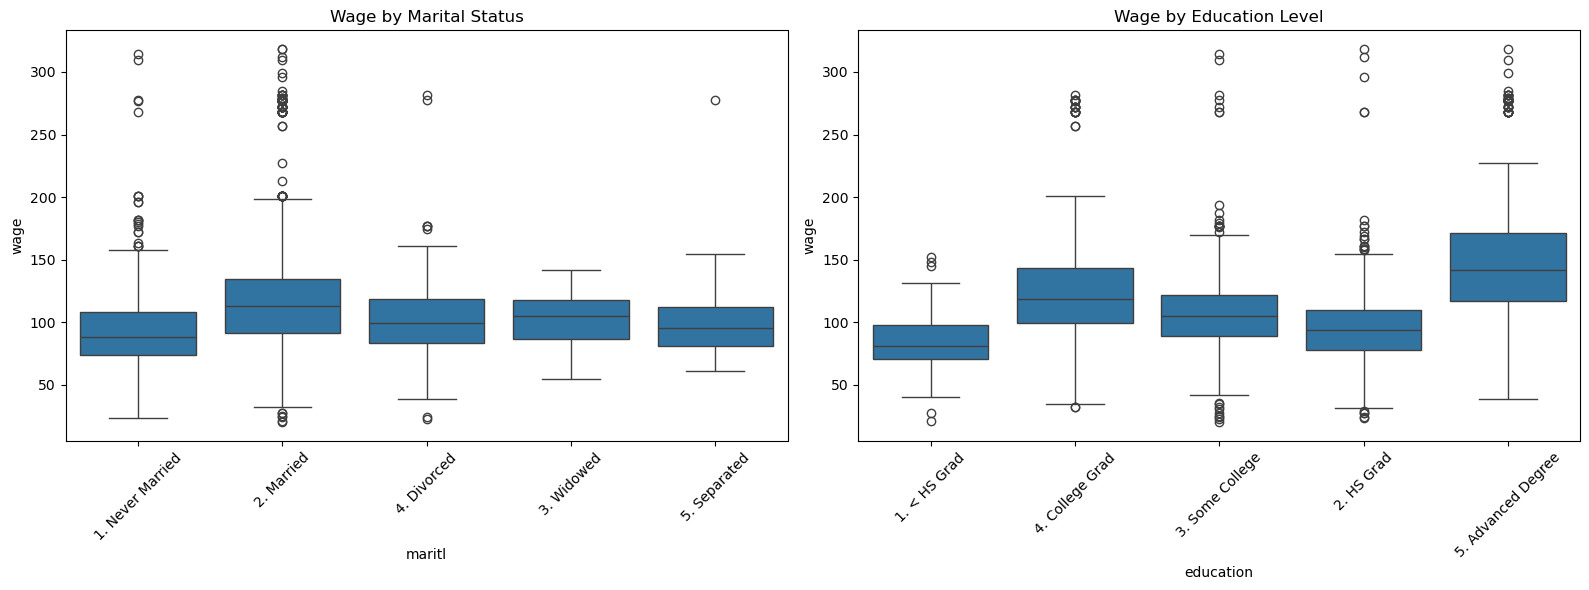

In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

wages = pd.read_csv("data/Wage.csv")

print("Maritl:")
print(wages["maritl"].value_counts())

print("\nEducation:")
print(wages["education"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x="maritl", y="wage", data=wages, ax=axes[0])
axes[0].set_title("Wage by Marital Status")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

sns.boxplot(x="education", y="wage", data=wages, ax=axes[1])
axes[1].set_title("Wage by Education Level")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [76]:
gam_model = smf.ols("wage ~ cr(age, df=4) + C(education) + C(maritl)", data=wages).fit()

print(gam_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     119.8
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          1.87e-227
Time:                        00:36:04   Log-Likelihood:                -14902.
No. Observations:                3000   AIC:                         2.983e+04
Df Residuals:                    2988   BIC:                         2.990e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

We explored the non-linear relationships between wage and several predictors using a Generalized Additive Model (GAM) approach. The model includes a cubic regression spline for age (with 4 degrees of freedom) alongside categorical variables for education and maritl status.

- Model Fit: Introducing education and marital status significantly improved the model performance, with the $R^2$ increasing to 0.306 (explaining 30.6% of the variance in wages), compared to less than 10% when using age alone.
- Education Impact: Education level proved to be the most influential predictor. Compared to the baseline of not completing high school, getting a High School Graduate status increases wage by 11.04, while obtaining an Advanced Degree yields the highest premium of 62.11. All education variables are highly statistically significant ($p < 0.001$).
- Marital Status Impact: Being married (2. Married) is highly significant and associated with a wage increase of 13.66 compared to never being married. Other marital statuses (Divorced, Widowed, Separated) do not show statistically significant differences from the baseline.

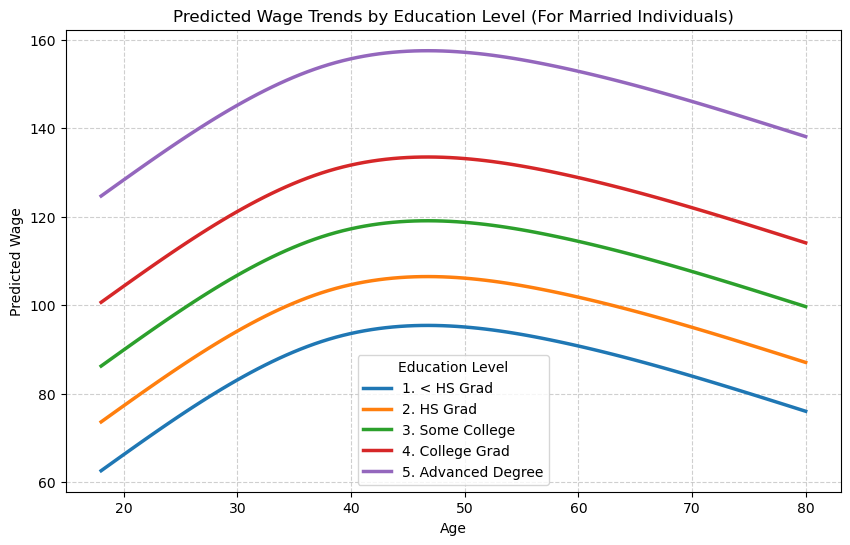

In [78]:
age_grid = np.linspace(wages["age"].min(), wages["age"].max(), 100)
education_levels = wages["education"].unique()
education_levels = sorted(education_levels)

plt.figure(figsize=(10, 6))

for edu in education_levels:
    pred_df = pd.DataFrame({
        "age": age_grid,
        "education": edu,
        "maritl": "2. Married"
    })
    
    predictions = gam_model.predict(pred_df)
    plt.plot(age_grid, predictions, label=edu, lw=2.5)

plt.xlabel("Age")
plt.ylabel("Predicted Wage")
plt.title("Predicted Wage Trends by Education Level (For Married Individuals)")
plt.legend(title="Education Level")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Task 8
Fit some of the non-linear models investigated in this chapter to the
Auto data set. Is there evidence for non-linear relationships in this
data set? Create some informative plots to justify your answer.

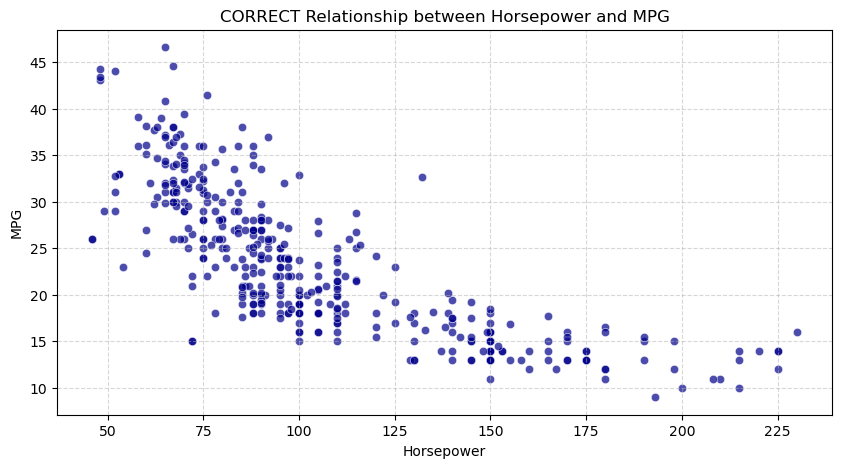

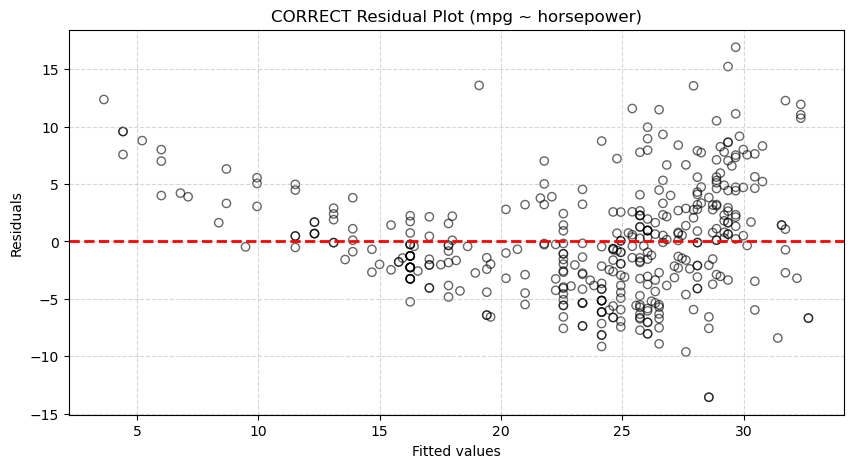

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

auto_data = pd.read_csv("data/Auto.csv")

auto_data["horsepower"] = pd.to_numeric(auto_data["horsepower"], errors="coerce")

auto_data = auto_data.dropna(subset=["horsepower"])

plt.figure(figsize=(10, 5))
sns.scatterplot(x="horsepower", y="mpg", data=auto_data, alpha=0.7, color="darkblue")
plt.title("CORRECT Relationship between Horsepower and MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

linear_model = smf.ols("mpg ~ horsepower", data=auto_data).fit()

plt.figure(figsize=(10, 5))
plt.scatter(linear_model.fittedvalues, linear_model.resid, alpha=0.6, facecolors="none", edgecolors="black")
plt.axhline(y=0, color="red", linestyle="--", lw=2)
plt.title("CORRECT Residual Plot (mpg ~ horsepower)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Based on the charts we can draw the next conclusions:
- The first chart will show a clear, smooth decreasing non-linear trend (as horsepower increases, MPG decreases quadratically, forming a distinct curve rather than a straight line).
- The residual plot will exhibit a textbook U-shaped pattern (curving upwards), which confirms that a simple linear model systematically underestimates or overestimates the target at different ranges of horsepower

In [5]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import SplineTransformer 

X_hp = auto_data[["horsepower"]].values
y_mpg = auto_data["mpg"].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 1. Linear model
lin_rmse = np.mean(-cross_val_score(LinearRegression(), X_hp, y_mpg, cv=kf, scoring="neg_root_mean_squared_error"))

# 2. 2-th degree polynomial
poly_model = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression())
poly_rmse = np.mean(-cross_val_score(poly_model, X_hp, y_mpg, cv=kf, scoring="neg_root_mean_squared_error"))

# 3. Natural Spline with df=4 (knots)
spline_model = make_pipeline(SplineTransformer(n_knots=4, degree=3, extrapolation="linear"), LinearRegression())
spline_rmse = np.mean(-cross_val_score(spline_model, X_hp, y_mpg, cv=kf, scoring="neg_root_mean_squared_error"))

print(f"Linear Model RMSE: {lin_rmse:.3f}")
print(f"Quadratic Polynomial RMSE: {poly_rmse:.3f}")
print(f"Cubic Spline RMSE: {spline_rmse:.3f}")

Linear Model RMSE: 4.909
Quadratic Polynomial RMSE: 4.364
Cubic Spline RMSE: 4.351


Visual Evidence: The initial scatter plot clearly displays a curvilinear trend, and the residual plot of the linear model exhibits a textbook U-shaped pattern, indicating systematic underestimation at the extremes and overestimation in the mid-range


Model Evaluation: Through 5-fold cross-validation, the baseline linear model performed poorly with an RMSE of 4.909. Incorporating non-linear techniques significantly reduced the error.

The Best Approach: The Cubic Spline (with 4 knots) achieved the best performance with an RMSE of 4.351, slightly outperforming the Quadratic Polynomial (RMSE: 4.364). This confirms that while the general trend resembles a parabola, the superior local flexibility of splines captures the true physical flattening of the MPG decay at higher horsepower levels without causing overfitting.

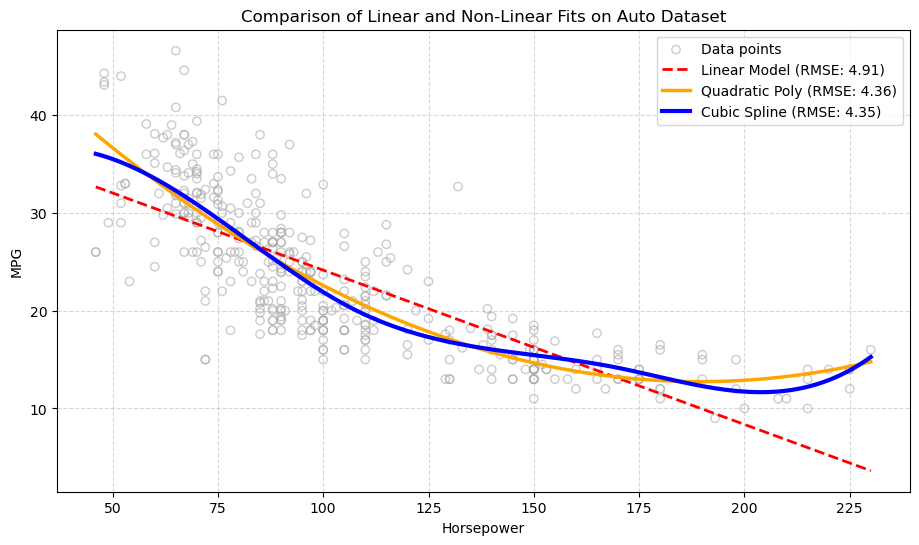

In [9]:
hp_grid = np.linspace(X_hp.min(), X_hp.max(), 1000).reshape(-1, 1)

# fit models
lin_full = LinearRegression().fit(X_hp, y_mpg)
poly_full = poly_model.fit(X_hp, y_mpg)
spline_full = spline_model.fit(X_hp, y_mpg)

# make predictions
y_lin_pred = lin_full.predict(hp_grid)
y_poly_pred = poly_full.predict(hp_grid)
y_spline_pred = spline_full.predict(hp_grid)

# plot graphs
plt.figure(figsize=(11, 6))
plt.scatter(X_hp, y_mpg, facecolors="none", edgecolors="darkgray", alpha=0.6, label="Data points")

plt.plot(hp_grid, y_lin_pred, color="red", linestyle="--", lw=2, label=f"Linear Model (RMSE: {lin_rmse:.2f})")
plt.plot(hp_grid, y_poly_pred, color="orange", lw=2.5, label=f"Quadratic Poly (RMSE: {poly_rmse:.2f})")
plt.plot(hp_grid, y_spline_pred, color="blue", lw=3, label=f"Cubic Spline (RMSE: {spline_rmse:.2f})")

plt.title("Comparison of Linear and Non-Linear Fits on Auto Dataset")
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

The linear model goes straight and do not see the real relationship. The quadratic polynomial is much closer to the real data, but strict natuaral constraint does not allow him catch all patterns. The cubic spline does catch needed patterns and on the top of that the additional constraints on the tails help him make better predictions

#### Task 9

This question uses the variables dis (the weighted mean of distances
to five Boston employment centers) and nox (nitrogen oxides concentration in parts per 10 million) from the Boston data. We will treat
dis as the predictor and nox as the response

Polynomial Regression (Degree 3) result
                            OLS Regression Results                            
Dep. Variable:                    nox   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     419.3
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          2.71e-136
Time:                        14:53:46   Log-Likelihood:                 690.44
No. Observations:                 506   AIC:                            -1373.
Df Residuals:                     502   BIC:                            -1356.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept 

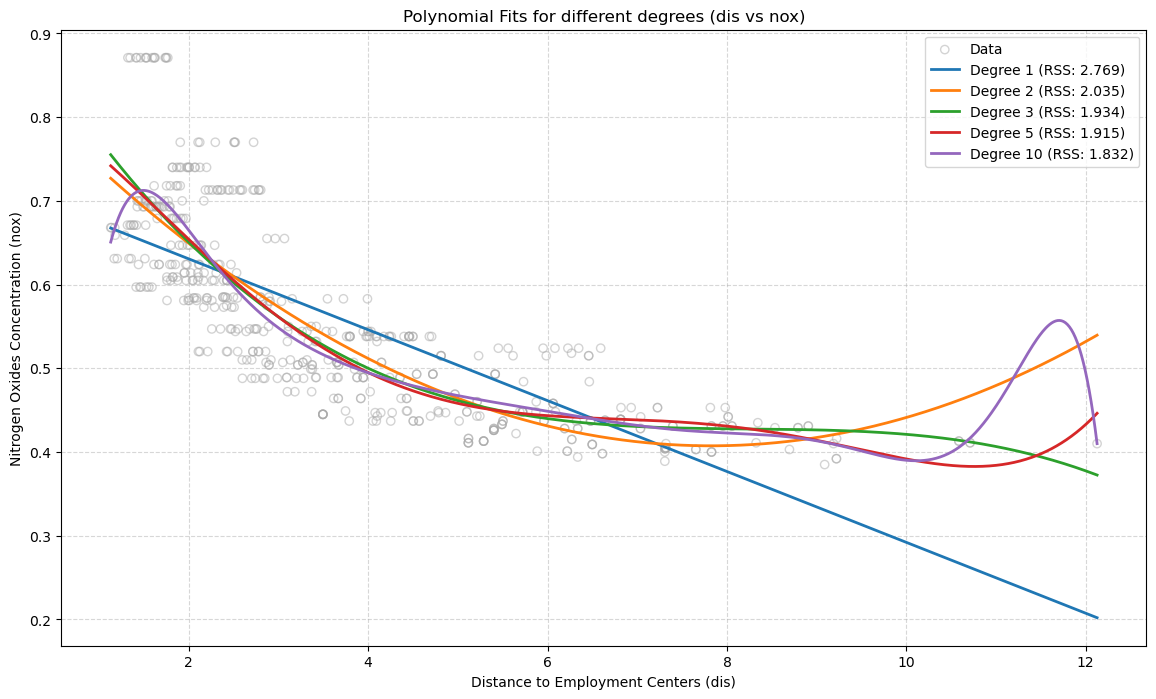

RSS for different degrees
Degree 1: RSS = 2.76856
Degree 2: RSS = 2.03526
Degree 3: RSS = 1.93411
Degree 4: RSS = 1.93298
Degree 5: RSS = 1.91529
Degree 6: RSS = 1.87826
Degree 7: RSS = 1.84948
Degree 8: RSS = 1.83563
Degree 9: RSS = 1.83333
Degree 10: RSS = 1.83217


In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.preprocessing import PolynomialFeatures

# 1. load Boston dataset
boston = pd.read_csv("data/Boston.csv")

X_dis = boston[["dis"]].values
y_nox = boston["nox"].values

# a) Cubic polynomial
poly_3_model = smf.ols("nox ~ dis + I(dis**2) + I(dis**3)", data=boston).fit()
print("Polynomial Regression (Degree 3) result")
print(poly_3_model.summary())

# b) Comparing degrees form 1 till 10
rss_values = []
plt.figure(figsize=(14, 8))
plt.scatter(boston["dis"], boston["nox"], facecolors="none", edgecolors="darkgray", alpha=0.5, label="Data")

dis_grid = np.linspace(boston["dis"].min(), boston["dis"].max(), 1000).reshape(-1, 1)

for degree in range(1, 11):
    coeffs = np.polyfit(boston["dis"], boston["nox"], degree)
    
    y_pred = np.polyval(coeffs, boston["dis"])
    rss = np.sum((boston["nox"] - y_pred) ** 2)
    rss_values = np.append(rss_values, rss)
    
    if degree in [1, 2, 3, 5, 10]:
        grid_pred = np.polyval(coeffs, dis_grid)
        plt.plot(dis_grid, grid_pred, lw=2, label=f"Degree {degree} (RSS: {rss:.3f})")

plt.title("Polynomial Fits for different degrees (dis vs nox)")
plt.xlabel("Distance to Employment Centers (dis)")
plt.ylabel("Nitrogen Oxides Concentration (nox)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("RSS for different degrees")
for d, rss in enumerate(rss_values, 1):
    print(f"Degree {d}: RSS = {rss:.5f}")

Statistical Significance: For the cubic model (Degree 3), the OLS output indicates that all coefficient estimates are highly statistically significant (p < 0.001). The model yields an R^2 = 0.715 and a high F-statistic (419.3), demonstrating a strong non-linear fit that explains approximately 71.5% of the variance in nox concentrations.

RSS Trend: As mathematically expected, the Residual Sum of Squares (RSS) decreases monotonically on the training data as the polynomial degree increases—dropping from 2.76856 (Degree 1) down to 1.83217 (Degree 10).

Overfitting Risk: Although higher-degree polynomials (such as Degree 10) achieve the lowest training RSS, visual inspection reveals severe boundary instability. The tails of the high-degree curves fluctuate erratically at the extremes of the dis range (especially where \text{dis} > 10). This behavior is a classic indicator of overfitting, meaning that minimizing training RSS does not imply a better model for unseen data

In [8]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# c) Cross-Validation settings 10 folds
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_mse_scores = []

for degree in range(1, 11):
    poly_pipeline = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False), 
        LinearRegression()
    )
    scores = -cross_val_score(poly_pipeline, X_dis, y_nox, cv=kf, scoring="neg_mean_squared_error")
    cv_mse_scores.append(np.mean(scores))

print("CV MEAN SQUARED ERROR (MSE) FOR DEGREES 1-10")
for d, mse in enumerate(cv_mse_scores, 1):
    print(f"Degree {d}: CV MSE = {mse:.6f}")

CV MEAN SQUARED ERROR (MSE) FOR DEGREES 1-10
Degree 1: CV MSE = 0.005508
Degree 2: CV MSE = 0.004070
Degree 3: CV MSE = 0.003849
Degree 4: CV MSE = 0.003872
Degree 5: CV MSE = 0.004146
Degree 6: CV MSE = 0.005895
Degree 7: CV MSE = 0.011533
Degree 8: CV MSE = 0.004486
Degree 9: CV MSE = 0.004798
Degree 10: CV MSE = 0.033986


Based on cross-validation approach with 10 folds, the best degree is 3 with MSE = 0.003849

Median of dis (automatic knot location): 3.207

REGRESSION SPLINE WITH DF=4 OUTPUT
                            OLS Regression Results                            
Dep. Variable:                    nox   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     316.5
Date:                Thu, 25 Jun 2026   Prob (F-statistic):          1.39e-135
Time:                        15:05:27   Log-Likelihood:                 691.93
No. Observations:                 506   AIC:                            -1374.
Df Residuals:                     501   BIC:                            -1353.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

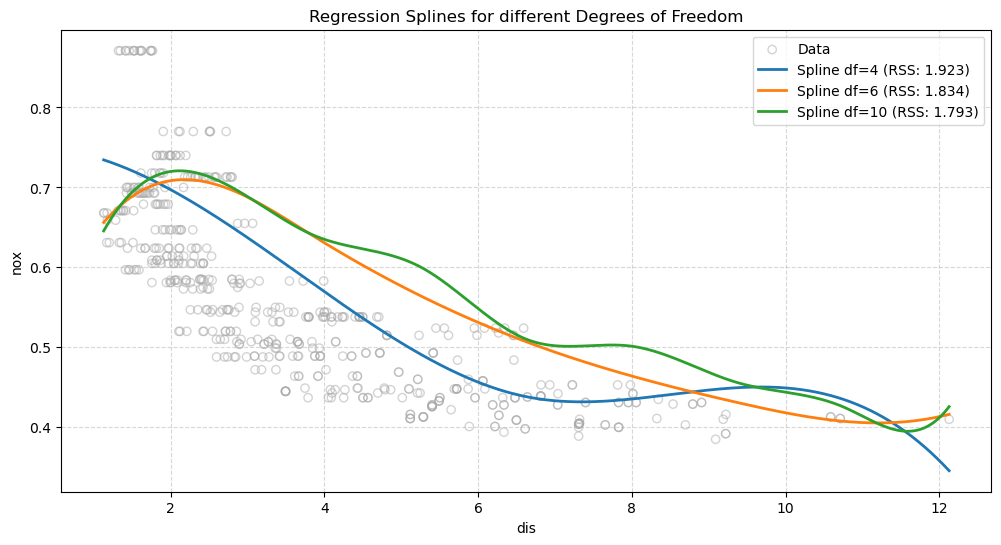

In [9]:
import patsy
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error

# choose the knots
dis_median = boston["dis"].median()
print(f"Median of dis (automatic knot location): {dis_median:.3f}\n")

# d) Regression Spline with df=4
spline_4_model = smf.ols("nox ~ patsy.bs(dis, df=4)", data=boston).fit()
print("REGRESSION SPLINE WITH DF=4 OUTPUT")
print(spline_4_model.summary())

# e) Splines with different df
print("SPLINE RSS FOR DIFFERENT DEGREES OF FREEDOM")
df_range = range(3, 11)
spline_rss = []

plt.figure(figsize=(12, 6))
plt.scatter(boston["dis"], boston["nox"], facecolors="none", edgecolors="darkgray", alpha=0.5, label="Data")

for df_val in df_range:
    model = smf.ols(f"nox ~ patsy.bs(dis, df={df_val})", data=boston).fit()
    
    rss = np.sum(model.resid ** 2)
    spline_rss.append(rss)
    print(f"df = {df_val}: RSS = {rss:.5f}")
    
    if df_val in [4, 6, 10]:
        preds = model.predict(pd.DataFrame({"dis": dis_grid.flatten()}))
        plt.plot(dis_grid, preds, lw=2, label=f"Spline df={df_val} (RSS: {rss:.3f})")

plt.title("Regression Splines for different Degrees of Freedom")
plt.xlabel("dis")
plt.ylabel("nox")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Knot Selection: For a standard cubic regression spline (bs()), the relation between the degrees of freedom and internal knots is given by \text{Internal Knots} = \text{df} - \text{degree}. Since the default degree is 3 (cubic), specifying \text{df}=4 results in exactly 1 internal knot. By default, this knot is automatically chosen at the 50th percentile (the median) of the predictor, which for dis is 3.207. This single knot partitions the dataset into two distinct regions, fitting a separate cubic polynomial on each side while ensuring continuous and smooth derivatives at the boundary

Model Summary: The OLS summary shows that all spline basis coefficients are highly statistically significant (p < 0.01). The model achieves an R^2 = 0.716 (Adjusted R^2 = 0.714) and an F-statistic of 316.5, capturing the non-linear relationship robustly.

RSS Trend: As the degrees of freedom increase from df=3 to df=10, the training RSS decreases monotonically from 1.93411 down to 1.79253. This occurs because more knots allow the model greater local flexibility.

Wiggliness & Overfitting: Visually, as df increases (e.g., df=6 and df=10), the regression curves begin to exhibit a wave-like behavior ("wiggliness"), noticeably lifting above the sparse data points in the $\text{dis} \in [4, 8]$ range. This happens because the model overfits the high-density region on the left, causing geometric compensation oscillations further down the axis. This serves as clear evidence that minimizing training RSS via high df introduces unnecessary variance

In [11]:
from sklearn.base import BaseEstimator, RegressorMixin

class PatsySplineRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, df=4):
        self.df = df
    def fit(self, X, y):
        df_train = pd.DataFrame({"X": X.flatten(), "y": y})
        self.model_ = smf.ols(f"y ~ patsy.bs(X, df={self.df})", data=df_train).fit()
        return self
    def predict(self, X):
        df_test = pd.DataFrame({"X": X.flatten()})
        return self.model_.predict(df_test)

cv_spline_mse = []
df_options = range(3, 11)

for df_val in df_options:
    spline_reg = PatsySplineRegressor(df=df_val)
    scores = -cross_val_score(spline_reg, X_dis, y_nox, cv=kf, scoring="neg_mean_squared_error")
    cv_spline_mse.append(np.mean(scores))

print("CV MSE FOR REGRESSION SPLINES (df 3-10)")
for df_val, mse in zip(df_options, cv_spline_mse):
    print(f"df = {df_val}: CV MSE = {mse:.6f}")


CV MSE FOR REGRESSION SPLINES (df 3-10)
df = 3: CV MSE = 0.005001
df = 4: CV MSE = 0.004661
df = 5: CV MSE = 0.004166
df = 6: CV MSE = 0.004139
df = 7: CV MSE = 0.004073
df = 8: CV MSE = 0.003964
df = 9: CV MSE = 0.003908
df = 10: CV MSE = 0.003872


Statistical Results: Mathematically, the validation Mean Squared Error (MSE) reaches its absolute minimum at $df = 10$ (CV MSE = 0.003872)

Analysis & Model Selection: While $df=10$ yields the lowest numerical error, it does so by forcing the cubic spline to introduce artificial wave-like oscillations ("wiggliness") to fit local dense pockets of data. Following the One-Standard-Error Rule and prioritizing model parsimony, choosing $df = 6$ or $df = 7$ (CV MSE $\approx$ 0.0041) is a much more robust and practical choice. These intermediate degrees of freedom sufficiently capture the steep non-linear drop on the left without introducing unphysical fluctuations in the mid-to-high distance range, providing a superior balance on the bias-variance tradeoff.